## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from rdkit import Chem

## Loading and Viewing the Original Dataset

In [55]:
# creating a variable to store the absolute .csv file path for the original Reaxys dataset
original_reaxys_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_dataset/reaxys_data_rearr.csv'

# reading in the dataset as stored in the path variable
original_reaxys = pd.read_csv(original_reaxys_path)

# viewing number of unique chromophores and solvents within the original Reaxys dataset
original_reaxys_chroms = original_reaxys['Chromophore'].unique()
print(f'Number of unique chromophores in the original Reaxys subset: {len(original_reaxys_chroms)}')

original_reaxys_solvs = original_reaxys['Solvent'].unique()
print(f'Number of unique solvents in the original Reaxys subset: {len(original_reaxys_solvs)}')

Number of unique chromophores in the original Reaxys subset: 33422
Number of unique solvents in the original Reaxys subset: 17


In [51]:
# printing the index and heading of each column in the dataset
for i, col in enumerate(original_reaxys.columns):
    print(i, repr(col))

# viewing the shape (no. entries) and title of columns contained by the data
print('Shape:', original_reaxys.shape)
print('\nColumns:')
for col in original_reaxys.columns:
    print(repr(col))

# checking for missing values within the original Reaxys dataset
print('\nMissing values:')
print(original_reaxys.isnull().sum())

0 'Chromophore'
1 'Solvent'
2 'Absorption max (nm)'
3 'log(e/mol-1 dm3 cm-1)'
4 'Reaxys Registry Number'
Shape: (33768, 5)

Columns:
'Chromophore'
'Solvent'
'Absorption max (nm)'
'log(e/mol-1 dm3 cm-1)'
'Reaxys Registry Number'

Missing values:
Chromophore               0
Solvent                   0
Absorption max (nm)       0
log(e/mol-1 dm3 cm-1)     0
Reaxys Registry Number    0
dtype: int64


## Loading and Viewing the Full Dataset

In [54]:
# creating a variable to store the absolute .csv file path for the full Reaxys dataset
full_reaxys_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_dataset/reaxys_data.csv'

# reading in the dataset as stored in the path variable
full_reaxys = pd.read_csv(full_reaxys_path)

# viewing number of unique chromophores and solvents within the full Reaxys dataset
full_reaxys_chroms = full_reaxys['Chromophore'].unique()
print(f'Number of unique chromophores in the full Reaxys subset: {len(full_reaxys_chroms)}')

full_reaxys_solvs = full_reaxys['Solvent'].unique()
print(f'Number of unique solvents in the full Reaxys subset: {len(full_reaxys_solvs)}')

Number of unique chromophores in the full Reaxys subset: 36777
Number of unique solvents in the full Reaxys subset: 18


In [53]:
# printing the index and heading of each column in the dataset
for i, col in enumerate(full_reaxys.columns):
    print(i, repr(col))

# viewing the shape (no. entries) and title of columns contained by the data
print('Shape:', full_reaxys.shape)
print('\nColumns:')
for col in full_reaxys.columns:
    print(repr(col))

# checking for missing values within the full Reaxys dataset
print('\nMissing values:')
print(full_reaxys.isnull().sum())

0 'Chromophore'
1 'Solvent'
2 'Absorption max (nm)'
3 'log(e/mol-1 dm3 cm-1)'
4 'Reaxys Registry Number'
Shape: (55866, 5)

Columns:
'Chromophore'
'Solvent'
'Absorption max (nm)'
'log(e/mol-1 dm3 cm-1)'
'Reaxys Registry Number'

Missing values:
Chromophore               0
Solvent                   0
Absorption max (nm)       0
log(e/mol-1 dm3 cm-1)     0
Reaxys Registry Number    0
dtype: int64


### Comments:

33,768 unique chromophores in original Reaxys dataset unlike ~38k as reported by authors - altering the extraction script (following initial value limits to prevent overflow errors) to write new, unique solvents and naming conventions to the solvent dictionary and to extract all spectra for a given chromophore led to obtaining 36,777 in the full dataset (remaining discrepancy attributed to changes in the Reaxys database since the authors conducted their research)

Column names were originally slightly different and in different order than the Deep4Chem dataset - changed extraction script so following analysis will be generalisable across datasets

## Investigating Solvent Distribution

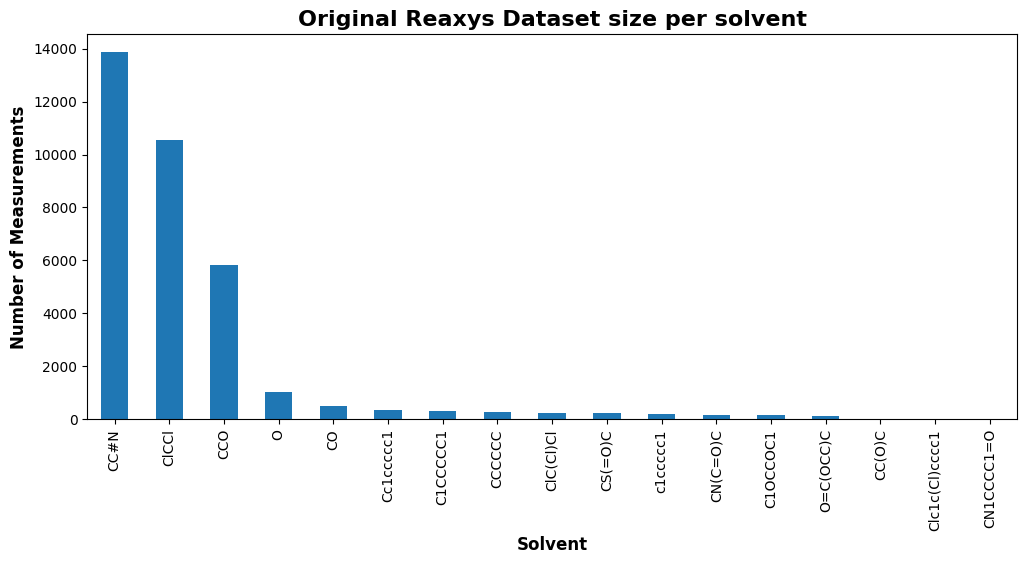

In [43]:
# obtaining frequencies of each solvent within the originally extracted Reaxys dataset
original_reaxys_solv_counts = original_reaxys['Solvent'].value_counts()

# creating a plot to visualise the frequency of each unique solvent within the original Reaxys dataset
plt.figure(figsize=(12,5))
original_reaxys_solv_counts.plot(kind='bar')
plt.ylabel('Number of Measurements', fontsize=12, weight='bold')
plt.xlabel('Solvent', fontsize=12, weight='bold')
plt.xticks(rotation=90)
plt.title('Original Reaxys Dataset size per solvent', fontsize=16, weight='bold')
plt.show()

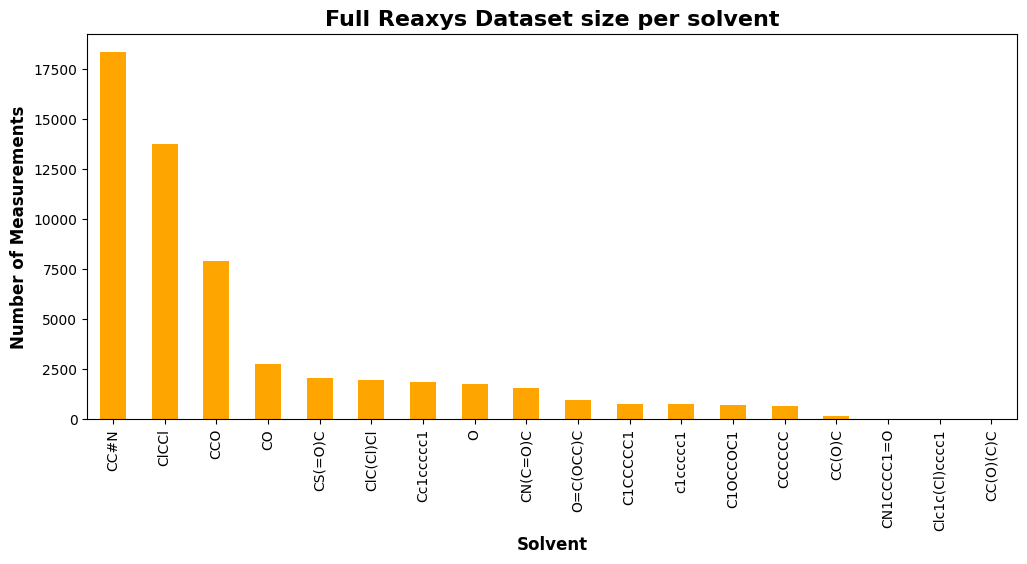

In [48]:
# obtaining frequencies of each solvent within the fully extracted Reaxys dataset
full_reaxys_solv_counts = full_reaxys['Solvent'].value_counts()

# creating a plot to visualise the frequency of each unique solvent within the full Reaxys dataset
plt.figure(figsize=(12,5))
full_reaxys_solv_counts.plot(kind='bar', color='orange')
plt.ylabel('Number of Measurements', fontsize=12, weight='bold')
plt.xlabel('Solvent', fontsize=12, weight='bold')
plt.xticks(rotation=90)
plt.title('Full Reaxys Dataset size per solvent', fontsize=16, weight='bold')
plt.show()

### Comments:
17 unique solvents present in the original Reaxys dataset unlike 4 as reported in the authors' SI (in order of frequency observed in this chart: ACN, DCM, EtOH, and water)

Top 3 most frequent solvents are shared between both Reaxys datasets - full dataset additionally contains measurements in the solvent tert-butanol (CC(O)(C)C), but otherwise all unique solvents are the same, albeit with different relative frequencies between both datasets

## Comparing Extracted and Original Registry Numbers

In [57]:
# creating a variable to store the absolute .csv file path for the Reaxys registry numbers
registry_nos_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/reaxys_dataset/reaxys_registry_numbers.csv'
# reading in the dataset as stored in the path variable
registry_nos = pd.read_csv(registry_nos_path)

# creating separate sets containing the original and extracted Reaxys IDs from the registry numbers and dataset CSV files, respectively
# sets used for this as they don't allow duplicate values, therefore the issue of duplicates discussed in a previous report are simply overcome here
# '.astype(str).str.replace(';', '', regex=False)' added to following line due to a ValueError raised corresponding to attempting to convert each entry
# containing a semicolon into an integer - data converted to strings to remove this character, then converted into integers
reaxys_ids = set(registry_nos.stack().dropna().astype(str).str.replace(';', '', regex=False).astype(int))
original_extracted_ids = set(original_reaxys['Reaxys Registry Number'].astype(int))
full_extracted_ids = set(full_reaxys['Reaxys Registry Number'].astype(int))

# obtaining the set of missing entries, sorted (by default) in ascending order
original_missing = sorted(reaxys_ids - original_extracted_ids)
full_missing = sorted(reaxys_ids - full_extracted_ids)

# printing the length and some examples of the missing Reaxys registry numbers
print(f'Number of missing registry numbers in the original Reaxys subset: {len(original_missing)}')
print(original_missing[:20])

print(f'\nNumber of missing registry numbers in the full Reaxys subset: {len(full_missing)}')
print(full_missing[:20])

Number of missing registry numbers in the original Reaxys subset: 3476
[2984, 3107, 3201, 3216, 3259, 5452, 6067, 7087, 7241, 8293, 8463, 11395, 14752, 17485, 19171, 22518, 25312, 28151, 40498, 41567]

Number of missing registry numbers in the full Reaxys subset: 66
[74052, 3785765, 4162751, 6076034, 11224347, 12292418, 15828734, 18461229, 18600510, 18817874, 18837873, 18837874, 19311378, 19311380, 19676415, 19984575, 20781134, 22449787, 22483419, 23120687]


In [62]:
# creating a DataFrame of missing registry numbers from the original Reaxys dataset, then saving it as a CSV file
original_missing_df = pd.DataFrame({'Reaxys Registry Number': [f'{x};' for x in original_missing]})
original_missing_df.to_csv('original_missing_registry_numbers.csv', index=False)

# printing the length of missing registry numbers from the original Reaxys dataset to confirm all, as investigated in the previous cell, are present
print(f'{len(original_missing_df)} missing registry numbers saved to CSV file corresponding to the original Reaxys dataset')

3476 missing registry numbers saved to CSV file corresponding to the original Reaxys dataset


In [63]:
# creating a DataFrame of missing registry numbers from the full Reaxys dataset, then saving it as a CSV file
full_missing_df = pd.DataFrame({'Reaxys Registry Number': [f'{x};' for x in full_missing]})
full_missing_df.to_csv('full_missing_registry_numbers.csv', index=False)

# printing the length of missing registry numbers from the full Reaxys dataset to confirm all, as investigated in the previous cell, are present
print(f'{len(full_missing_df)} missing registry numbers saved to CSV file corresponding to the full Reaxys dataset')

66 missing registry numbers saved to CSV file corresponding to the full Reaxys dataset


In [26]:
# obtaining original extracted Reaxys database's unique chromophore UV/Vis spectra counts
original_counts = (original_reaxys.groupby('Reaxys Registry Number').size().reset_index(name='Extracted spectra'))

In [64]:
# creating a DataFrame of Reaxys registry numbers (from the CSV file provided by the authors) integers (after ignoring the semicolons present in the 
# aforementioned CSV file for clarity), then joining it with the number of extracted spectra within the original Reaxys dataset, matching rows by and 
# retaining all registry numbers from the newly-created DataFrame
original_comparison = (registry_nos.stack().dropna().astype(str).str.replace(';', '', regex=False).astype(int).to_frame(name='Reaxys Registry Number')
    .merge(original_counts, how='left', on='Reaxys Registry Number'))

# replacing missing values in the extracted spectra column with 0 and converting the column to integers before viewing the original comparison 
# DataFrame's first 20 values
original_comparison['Extracted spectra'] = original_comparison['Extracted spectra'].fillna(0).astype(int)
original_comparison.head(20)

,Reaxys Registry Number,Extracted spectra
0,5754082,1
1,5118451,1
2,4464078,1
3,6224925,1
4,5063138,1
5,5769549,1
6,5127449,1
7,4639287,1
8,4459463,1
9,307943,1


In [27]:
# obtaining original extracted Reaxys database's unique chromophore UV/Vis spectra counts
full_counts = (full_reaxys.groupby('Reaxys Registry Number').size().reset_index(name='Extracted spectra'))

In [65]:
# creating a DataFrame of Reaxys registry numbers (from the CSV file provided by the authors) integers (after ignoring the semicolons present in the 
# aforementioned CSV file for clarity), then joining it with the number of extracted spectra within the full Reaxys dataset, matching rows by and 
# retaining all registry numbers from the newly-created DataFrame
full_comparison = (registry_nos.stack().dropna().astype(str).str.replace(';', '', regex=False).astype(int).to_frame(name='Reaxys Registry Number')
                   .merge(full_counts, how='left', on='Reaxys Registry Number'))

# replacing missing values in the extracted spectra column with 0 and converting the column to integers before viewing the full comparison DataFrame's 
# first 20 values
full_comparison['Extracted spectra'] = full_comparison['Extracted spectra'].fillna(0).astype(int)
full_comparison.head(20)

,Reaxys Registry Number,Extracted spectra
0,5754082,5
1,5118451,1
2,4464078,1
3,6224925,1
4,5063138,1
5,5769549,1
6,5127449,4
7,4639287,1
8,4459463,1
9,307943,3


### Comments:

After amending the authors' target property extraction script, as described, only 66 registry numbers were missing from the "full" Reaxys dataset compared to the ~3.5k registry numbers missing within the originally-extracted Reaxys dataset - remaining differences are attributed to changes within the Reaxys database, as also mentioned, and the former dataset will be used with the Chemprop package moving forward as it is larger and more completely represents the information initially exported from the database

The original comparison DataFrame demonstrates where extraction failed on specific registry numbers, and that only the first spectrum for each chromophore was extracted using the authors' original target property extraction script (its only amendment at this stage being limitations on the magnitude of the target property values it should extract to avoid errors using this script and with Chemprop commands)

The full comparison DataFrame again demonstrates where extraction failed on specific registry numbers, but also which registry numbers contained multiple spectra following exportation from the Reaxys website that were successfully extracted after amending the authors' provided script

## Splitting Full Reaxys Dataset

In [69]:
# viewing number of unique molecules (chromophores) in the full Reaxys dataset
print(len(full_reaxys_chroms))

# creating training and testing subsets of specified sizes w.r.t chromophore SMILES entry - DataFrames created include molecules specified in the 
# following line by the 'unique_mols' dataframe, resulting in the subsets being of lengths determined by the number of unique molecule + solvent 
# combinations that correspond
train_mols, test_mols = train_test_split(full_reaxys_chroms, test_size=0.26, random_state=0)
train_df = full_reaxys[full_reaxys['Chromophore'].isin(train_mols)]
test_df = full_reaxys[full_reaxys['Chromophore'].isin(test_mols)]

# printing the shape of each subset, as well as a confirmation that the test set contains 1000 molecules while the rest comprise the training set
print(train_df.shape)
print(test_df.shape)
print(train_df['Chromophore'].nunique())
print(test_df['Chromophore'].nunique())

36777
(41375, 5)
(14491, 5)
27214
9563


In [70]:
# creating CSV files for each of the Reaxys subsets for future reference and analysis
train_df.to_csv('reaxys_train.csv', index=False)
test_df.to_csv('reaxys_test.csv', index=False)

In [ ]:
# viewing the training set to ensure it saved correctly - also to compare to following test set to view each's immediate chromophore SMILES entries
pd.read_csv('reaxys_train.csv').head()

In [ ]:
# viewing the test set to ensure it saved correctly - also to compare to previous training set to view each's immediate chromophore SMILES entries
pd.read_csv('reaxys_test.csv').head()

In [97]:
# dropping Reaxys registry number column for the training subset
train_no_nums = train_df.drop('Reaxys Registry Number', axis=1)

In [98]:
# dropping Reaxys registry number column for the test subset
test_no_nums = test_df.drop('Reaxys Registry Number', axis=1)

In [99]:
# creating CSV files for each of the Reaxys subsets excluding registry numbers for future reference and analysis
train_no_nums.to_csv('reaxys_train_no_reg_nums.csv', index=False)
test_no_nums.to_csv('reaxys_test_no_reg_nums.csv', index=False)

In [ ]:
# viewing the training set to ensure it saved correctly - also to compare to following test set to view each's immediate chromophore SMILES entries
pd.read_csv('reaxys_train_no_reg_nums.csv').head()

In [ ]:
# viewing the test set to ensure it saved correctly - also to compare to following test set to view each's immediate chromophore SMILES entries
pd.read_csv('reaxys_test_no_reg_nums.csv').head()

### Comments:

26% of full Reaxys dataset (~9.6k unique chromophores) included in test subset instead of 1k molecules as the authors used so that Chemprop model performance could be analysed more fairly between the Deep4Chem and Reaxys datasets

The Deep4Chem dataset (3.8k unique chromophores) was split into a 1k unique chromophore test set and remaining (~2.8k) training subset - this corresponds to ~74% of the full dataset contained within the training subset, and remaining ~26% contained by the test subset => relative split reproduced with the larger Reaxys subset for a more meaningful comparison between model performance between the datasets

## Splitting Reaxys Train Subset for Hyperparameter Optimisation

In [107]:
# creating smaller subset from the training set excluding Reaxys registry numbers (same method as authors used for hyperparameter optimisation)
hpopt_df = train_no_nums.sample(n=6000, random_state=0)

# printing the shape of the subset, and the number of unique chromophores it corresponds to
print(hpopt_df.shape)
print(hpopt_df['Chromophore'].nunique())

(6000, 4)
5436


In [109]:
# creating CSV files for the Reaxys subset excluding registry numbers for future use
hpopt_df.to_csv('reaxys_train_hpopt.csv', index=False)

In [ ]:
# viewing the hyperparameter optimisation subset to ensure it saved correctly
pd.read_csv('reaxys_train_hpopt.csv').head()

### Comments: 

Chemprop v2 hyperparameter optimisation timed out on the 16 CPU core HPC cluster using the full Reaxys training subset, so it was reduced so values could be obtained feasibly

Authors only used a 1k molecule subset of both the Deep4Chem and Reaxys training sets, but hyperparameters were obtained relatively quickly using all ~6k datapoints in the Deep4Chem training subset during modern hyperoptimisation with the package and produced improved results compared to its older implementation => 6k datapoints extracted from the Reaxys training set so both datasets were treated the same during this process and to obtain values more reflective of the Reaxys' chemistry

## **Removing Invalid SMILES from Reaxys Datasets**

In [3]:
# reading in the Reaxys datasets
train = pd.read_csv('reaxys_train_no_reg_nums.csv')
test = pd.read_csv('reaxys_test_no_reg_nums.csv')

In [4]:
# defining function to check if SMILES strings are valid - not missing and can be converted into a real molecule
def valid_smiles(smiles):
    if pd.isna(smiles):
        return False
    return Chem.MolFromSmiles(str(smiles)) is not None

# creating masks identifying rows where both the chromophore and solvent SMILES are valid, for both Reaxys subsets
train_valid_mask = (train['Chromophore'].apply(valid_smiles) & train['Solvent'].apply(valid_smiles))
test_valid_mask = (test['Chromophore'].apply(valid_smiles) & test['Solvent'].apply(valid_smiles))

# extracting rows containing at least one invalid SMILES entry for both datasers
train_invalid = train.loc[~train_valid_mask]
test_invalid = test.loc[~test_valid_mask]

# retaining only valid rows for both datasets
train_filtered = train.loc[train_valid_mask].reset_index(drop=True)
test_filtered = test.loc[test_valid_mask].reset_index(drop=True)

[21:23:23] Explicit valence for atom # 3 C, 5, is greater than permitted


In [5]:
# reporting the original dataset size, number of rows removed, and remaining valid rows for the training dataset
print('Training Dataset:')
print(f'Original rows: {len(train)}')
print(f'Invalid rows removed: {len(train_invalid)}')
print(f'Remaining rows: {len(train_filtered)}')

# reporting the original dataset size, number of rows removed, and remaining valid rows for the test dataset
print('\nTest Dataset:')
print(f'Original rows: {len(test)}')
print(f'Invalid rows removed: {len(test_invalid)}')
print(f'Remaining rows: {len(test_filtered)}')

Training Dataset:
Original rows: 41375
Invalid rows removed: 1
Remaining rows: 41374

Test Dataset:
Original rows: 14491
Invalid rows removed: 0
Remaining rows: 14491


In [6]:
# saving valid datasets to use with Chemprop
train_filtered.to_csv('reaxys_train_filtered_no_reg_nums.csv', index=False)
test_filtered.to_csv('reaxys_test_filtered_no_reg_nums.csv', index=False)

### Comments:

Only one SMILES input in the entire dataset was initially removed, due to an explicit carbon valence of 5